In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Block 1: Check TensorFlow and Keras setup
# --------------------------------------------
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)   # fixed: use tf.keras, not keras directly
print("GPU devices:")
print(tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
Keras version: 3.15.1
GPU devices:
[]


In [3]:
# Block 2: Load dataset
# --------------------------------------------
try:
    df = pd.read_csv("diabetes.csv")
except FileNotFoundError:
    raise FileNotFoundError(
        "diabetes.csv not found. Place it in the same directory as this script, "
        "or provide the correct path."
    )

print("\nFirst 5 rows:")
print(df.head())
print("\nDataset information:")
df.info()
print("\nDataset shape:")
print(df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())


First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            2      138             62             35        0  33.6   
1            0       84             82             31      125  38.2   
2            0      145              0              0        0  44.2   
3            0      135             68             42      250  42.3   
4            1      139             62             41      480  40.7   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.127   47        1  
1                     0.233   23        0  
2                     0.630   31        1  
3                     0.365   24        1  
4                     0.536   21        0  

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   G

In [4]:
# Block 3: Separate input features and target
# --------------------------------------------
if "Outcome" not in df.columns:
    raise KeyError("Expected an 'Outcome' column in diabetes.csv")

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [5]:
# Block 4: Standardize the features
# --------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Block 5: Train-test split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y  # added: keeps class balance consistent across splits
)

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (1800, 8)
Testing shape: (200, 8)


In [7]:
# Block 6: Build the model
# --------------------------------------------
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),   # fixed: Input layer instead of input_shape kwarg
    layers.Dense(100, activation="relu"),
    layers.Dense(50, activation="relu"),
    layers.Dense(12, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,675 (26.07 KB)

 Trainable params: 6,675 (26.07 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Block 7: Compile the model
# --------------------------------------------
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
# Block 8: Train the model
# --------------------------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,                # added: explicit batch size for stable training
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7328 - loss: 0.5480 - val_accuracy: 0.8100 - val_loss: 0.4443
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7800 - loss: 0.4711 - val_accuracy: 0.8000 - val_loss: 0.4168
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7778 - loss: 0.4492 - val_accuracy: 0.8050 - val_loss: 0.4022
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7906 - loss: 0.4335 - val_accuracy: 0.8250 - val_loss: 0.3774
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8039 - loss: 0.4169 - val_accuracy: 0.8200 - val_loss: 0.3759
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8150 - loss: 0.3997 - val_accuracy: 0.8350 - val_loss: 0.3654
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8156 - loss: 0.3868 - val_accuracy: 0.8550 - val_loss: 0.3294
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8361 - loss: 0.3732 - val_accuracy: 0.8500 - val_loss:

In [10]:
# Block 9: Evaluate the model
# --------------------------------------------
test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=2
)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_acc)

7/7 - 0s - 9ms/step - accuracy: 0.9950 - loss: 0.0283

Test Loss: 0.028323214501142502
Test Accuracy: 0.9950000047683716


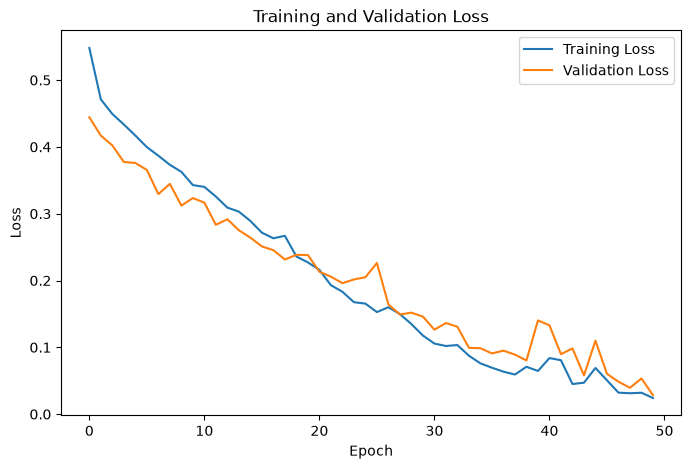

In [11]:
# Block 10: Plot training loss
# --------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.savefig("loss_plot.png")   # added: saves plot in case show() has no display backend
plt.show()

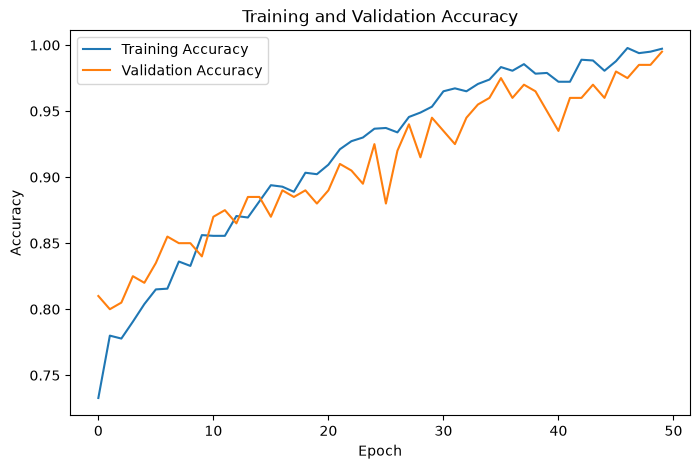

In [12]:
# Block 11: Plot training accuracy
# --------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.savefig("accuracy_plot.png")  # added
plt.show()

In [13]:
# Block 12: Make predictions
# --------------------------------------------
predictions = model.predict(X_test)
predicted_classes = (predictions >= 0.5).astype(int).flatten()  # fixed: flatten to 1D for clean comparison
print("\nPredicted:")
print(predicted_classes[:10])
print("\nActual:")
print(y_test.iloc[:10].values)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Predicted:
[1 1 0 0 0 1 0 0 0 0]

Actual:
[1 1 0 0 0 1 0 0 0 0]
